# Проект: ChemAI: Predict the Cure

Химики предоставили данные о свойствах молекул и их биологической активности против вируса гриппа. Наша задача — построить модели, способные предсказывать эффективность новых соединений.

Для каждого химического соединения необходимо предсказать три показателя:
- IC50 (mM) — концентрация, при которой вещество подавляет 50% активности вируса
- CC50 (mM) — концентрация, при которой вещество токсично для 50% клеток
- SI (Selectivity Index) — индекс селективности.

Задача оценивается по метрике RMSE (Root Mean Squared Error), усреднённый по трём таргетам:

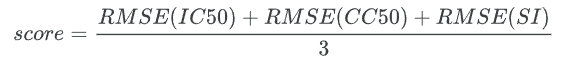

## 1. Загрузка данных

In [1]:
import sys

!{sys.executable} -m pip install -q catboost xgboost
!{sys.executable} -m pip install -q lightgbm

На этапе экспериментов мы пробовали разные семейства моделей, не только sklearn. Эти библиотеки нужны были для сравнения с ExtraTrees.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor
from sklearn.ensemble import IsolationForest

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [3]:
RANDOM_STATE = 42

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)


In [5]:
DATA_PATH = "../data"

print(os.listdir(DATA_PATH))

['sample_submission.csv', 'test.csv', 'train.csv']


In [6]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)

train: (751, 214)
test: (250, 211)
sample_submission: (250, 4)


In [7]:
train.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [8]:
test.head()

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


In [9]:
sample_submission.head()

,index,IC50,CC50,SI
0,0,0.723678,0.426328,0.308486
1,1,0.804617,0.643166,0.179750
2,2,0.907425,0.518521,0.298384
3,3,0.563266,0.054770,0.280019
4,4,0.935028,0.616856,0.979752


## 2. Исследование данных

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [11]:
train.isna().sum().sort_values(ascending=False).head(30)

MinAbsPartialCharge    2
BCUT2D_LOGPHI          2
BCUT2D_MWHI            2
MaxAbsPartialCharge    2
MinPartialCharge       2
MaxPartialCharge       2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
fr_N_O                 0
fr_NH1                 0
fr_NH0                 0
fr_Imine               0
fr_HOCCN               0
fr_C_S                 0
fr_C_O_noCOO           0
fr_NH2                 0
index                  0
fr_Ndealkylation1      0
fr_COO2                0
fr_Ndealkylation2      0
fr_Nhpyrrole           0
fr_SH                  0
fr_aldehyde            0
fr_alkyl_carbamate     0
fr_alkyl_halide        0
fr_allylic_oxid        0
dtype: int64

In [12]:
test.isna().sum().sort_values(ascending=False).head(30)

BCUT2D_MRLOW           1
BCUT2D_MRHI            1
BCUT2D_MWHI            1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
MinAbsPartialCharge    1
MaxAbsPartialCharge    1
MinPartialCharge       1
MaxPartialCharge       1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
fr_Ndealkylation2      0
fr_Ndealkylation1      0
fr_N_O                 0
fr_NH2                 0
fr_NH1                 0
fr_NH0                 0
fr_Imine               0
fr_HOCCN               0
index                  0
fr_Nhpyrrole           0
fr_C_O_noCOO           0
fr_SH                  0
fr_aldehyde            0
fr_alkyl_carbamate     0
fr_alkyl_halide        0
fr_allylic_oxid        0
fr_amide               0
fr_amidine             0
dtype: int64

In [7]:
TARGETS = ['IC50, mM', 'CC50, mM', 'SI']
SUBMISSION_TARGETS = ['IC50', 'CC50', 'SI']
ID_COL = 'index'

В train таргеты называются с единицами измерения, например IC50, mM, а в submission Kaggle ждёт короткие названия IC50, CC50, SI.

In [8]:
X_raw = train.drop(columns=TARGETS + [ID_COL])
X_test_raw = test.drop(columns=[ID_COL])
y = train[TARGETS].copy()


Отделяем признаки от целевых переменных, чтобы не было утечки таргетов в модель.

In [9]:
print("X_raw:", X_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y:", y.shape)

X_raw: (751, 210)
X_test_raw: (250, 210)
y: (751, 3)


In [10]:
# 1. Константные признаки
constant_cols = [
    col for col in X_raw.columns
    if X_raw[col].nunique(dropna=False) <= 1
]

print("Constant columns:", len(constant_cols))
print(constant_cols)

Constant columns: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


Найдено 18 признаков, у которых во всех строках одно и то же значение.
Константные признаки не помогают модели, потому что они не различают объекты. Поэтому их безопасно удалить.

In [11]:
# 2. Дублирующиеся признаки
duplicate_cols = []

cols = X_raw.drop(columns=constant_cols).columns.tolist()

for i, col in enumerate(cols):
    for prev_col in cols[:i]:
        if X_raw[col].equals(X_raw[prev_col]):
            duplicate_cols.append(col)
            break

print("Duplicate columns:", len(duplicate_cols))
print(duplicate_cols)

Duplicate columns: 6
['MaxEStateIndex', 'fr_COO2', 'fr_Nhpyrrole', 'fr_benzene', 'fr_nitro_arom_nonortho', 'fr_phenol_noOrthoHbond']


Здесь ищутся дублирующиеся признаки: колонки, которые полностью повторяют значения других колонок.
Если две колонки несут одну и ту же информацию, одну можно удалить. Это уменьшает размерность и шум.

In [12]:
drop_cols = list(set(constant_cols + duplicate_cols))

X_clean = X_raw.drop(columns=drop_cols)
X_test_clean = X_test_raw.drop(columns=drop_cols)

print("Dropped columns:", len(drop_cols))
print("X_clean:", X_clean.shape)
print("X_test_clean:", X_test_clean.shape)

Dropped columns: 24
X_clean: (751, 186)
X_test_clean: (250, 186)


Удаляем константные и дублирующиеся признаки из train и test.

In [13]:
train_feature_duplicates = X_clean.duplicated().sum()
test_feature_duplicates = X_test_clean.duplicated().sum()

print("Duplicate feature rows in train:", train_feature_duplicates)
print("Duplicate feature rows in test:", test_feature_duplicates)

Duplicate feature rows in train: 121
Duplicate feature rows in test: 24


Мы обнаружили, что в данных есть объекты с одинаковыми дескрипторами. Это важный момент, потому что одинаковые признаки в идеале должны вести к одинаковым таргетам, но в реальных лабораторных данных возможен шум.

In [14]:
train_keys = pd.util.hash_pandas_object(X_clean, index=False)
test_keys = pd.util.hash_pandas_object(X_test_clean, index=False)

train_key_set = set(train_keys)

matched_test_rows = test_keys.isin(train_key_set).sum()

print("Test rows with exact feature match in train:", matched_test_rows)

Test rows with exact feature match in train: 68


Мы проверили, сколько test-объектов имеют точное совпадение по дескрипторам с объектами из train. Это не используется в лучшем решении, но помогло понять структуру данных.

In [15]:
train_dup_analysis = X_clean.copy()
train_dup_analysis[TARGETS] = y

train_dup_analysis["_key"] = pd.util.hash_pandas_object(X_clean, index=False).astype(str)

dup_stats = (
    train_dup_analysis
    .groupby("_key")[TARGETS]
    .agg(["count", "mean", "std", "min", "max"])
)

# оставляем только группы, где есть дубли
dup_stats = dup_stats[dup_stats[('SI', 'count')] > 1]

print("Number of duplicate groups:", dup_stats.shape[0])

dup_stats.head(20)

Number of duplicate groups: 60


IC50, mM                                        \
                        count         mean          std         min   
_key                                                                  
10086807659238555796        2    72.365545    34.286610   48.121251   
10091642533791176640        3  1839.225423  1655.576553   32.843311   
10728266212960938981        2     0.729727     0.806442    0.159487   
10986573623536483370        2    14.590835    13.192585    5.262268   
11484883662977259668        2   158.033911   177.751722   32.344463   
12174236541213400051        3    78.064012    63.957644    4.212087   
12316857387158723294        2     5.549056     0.635597    5.099621   
12467743497049075298        2   101.254772    56.165165   61.540003   
12563429318639499167        2     9.608517     0.000000    9.608517   
13093208970010146220        2     7.715975     0.000000    7.715975   
13450303381186647066        2   355.228811   292.099868  148.683013   
13795675766250167077        2    43.391170    54.417470    4.912208   
14321467980797602575        3    71.668117    49.074193   15.002119   
14348673135967612565        2    59.455710     0.000000   59.455710   
14371804526256778352        3    25.600721    29.710075    3.584101   
14883935084838503899        2    10.658930     6.250196    6.239374   
15121209862443069914        3    72.200081    21.706107   58.011195   
15593619804075332110        2    60.189475    64.476367   14.597799   
16144124142474195317        2   550.565470   745.095477   23.703406   
16949400993903005983        2     7.107371     0.000000    7.107371   

                                  CC50, mM                           \
                              max    count         mean         std   
_key                                                                  
10086807659238555796    96.609840        2   377.255913  120.522629   
10091642533791176640  3284.331113        3  3284.331113    0.000000   
10728266212960938981     1.299968        2    99.998194    0.000000   
10986573623536483370    23.919401        2   806.323014   12.741557   
11484883662977259668   283.723358        2   334.793563  329.021246   
12174236541213400051   114.989975        3  2106.043502    0.000000   
12316857387158723294     5.998491        2   100.000452    0.000000   
12467743497049075298   140.969541        2  1753.174498   40.479398   
12563429318639499167     9.608517        2   304.269705    0.000000   
13093208970010146220     7.715975        2  1986.863553  600.162004   
13450303381186647066   561.774609        2   561.774609    0.000000   
13795675766250167077    81.870132        2   194.714464  110.571668   
14321467980797602575   100.001115        3    68.000312    0.000000   
14348673135967612565    59.455710        2    79.994955    1.273986   
14371804526256778352    59.393673        3  2119.739692  544.832423   
14883935084838503899    15.078486        2   759.773719  826.312733   
15121209862443069914    97.187587        3  1883.480370    0.000000   
15593619804075332110   105.781151        2   232.189628  204.200095   
16144124142474195317  1077.427534        2   636.759673  623.198466   
16949400993903005983     7.107371        2   300.819480  393.761266   

                                                  SI                          \
                              min          max count        mean         std   
_key                                                                           
10086807659238555796   292.033545   462.478281     2    5.427887    0.906249   
10091642533791176640  3284.331113  3284.331113     3   34.164179   57.016025   
10728266212960938981    99.998194    99.998194     2  351.961806  388.962745   
10986573623536483370   797.313373   815.332655     2   92.800909   83.034478   
11484883662977259668   102.140409   567.446717     2    2.578947    0.818755   
12174236541213400051  2106.043502  2106.043502     3  178.876679  278.100954   
12316857387158723294   100.000452

In [16]:
dup_spread = pd.DataFrame({
    "count": dup_stats[("SI", "count")],
    
    "IC50_mean": dup_stats[("IC50, mM", "mean")],
    "IC50_std": dup_stats[("IC50, mM", "std")],
    "IC50_min": dup_stats[("IC50, mM", "min")],
    "IC50_max": dup_stats[("IC50, mM", "max")],
    
    "CC50_mean": dup_stats[("CC50, mM", "mean")],
    "CC50_std": dup_stats[("CC50, mM", "std")],
    "CC50_min": dup_stats[("CC50, mM", "min")],
    "CC50_max": dup_stats[("CC50, mM", "max")],
    
    "SI_mean": dup_stats[("SI", "mean")],
    "SI_std": dup_stats[("SI", "std")],
    "SI_min": dup_stats[("SI", "min")],
    "SI_max": dup_stats[("SI", "max")],
})

dup_spread.sort_values("SI_std", ascending=False).head(20)

,count,IC50_mean,IC50_std,IC50_min,IC50_max,CC50_mean,CC50_std,CC50_min,CC50_max,SI_mean,SI_std,SI_min,SI_max
_key,,,,,,,,,,,,,
4972505171501264594,7,0.316502,0.485677,0.003517,1.399644,87.928898,82.372200,19.999437,250.001758,2694.841865,4518.031640,71.447236,11848.333333
8093754041653173835,16,9.475038,14.233891,0.016004,49.898692,242.241640,480.599295,0.700995,1805.081735,1470.412209,3923.379588,0.027594,15620.600000
18396002225371838087,3,2.620586,1.939057,0.393088,3.930879,1965.439708,0.000000,1965.439708,1965.439708,2018.518519,2582.188117,500.000000,5000.000000
10728266212960938981,2,0.729727,0.806442,0.159487,1.299968,99.998194,0.000000,99.998194,99.998194,351.961806,388.962745,76.923611,627.000000
14371804526256778352,3,25.600721,29.710075,3.584101,59.393673,2119.739692,544.832423,1510.442534,2560.072092,283.062549,318.072743,25.431034,638.571429
12174236541213400051,3,78.064012,63.957644,4.212087,114.989975,2106.043502,0.000000,2106.043502,2106.043502,178.876679,278.100954,18.315018,500.000000
2248760229184499921,2,4.745148,6.173800,0.379612,9.110683,664.320666,671.065211,189.805904,1138.835427,312.500000,265.165043,125.000000,500.000000
10986573623536483370,2,14.590835,13.192585,5.262268,23.919401,806.323014,12.741557,797.313373,815.332655,92.800909,83.034478,34.086667,151.515152
13093208970010146220,2,7.715975,0.000000,7.715975,7.715975,1986.863553,600.162004,1562.484930,2411.242176,257.500000,77.781746,202.500000,312.500000


Создаётся dup_spread — таблица статистик по дубликатным группам:

- count;
- средние значения IC50, CC50, SI;
- стандартные отклонения;
- min/max;
- коэффициенты вариации.

Оцениваем, насколько сильно расходятся таргеты у одинаковых молекулярных дескрипторов.

Вывод: одинаковые дескрипторы не всегда дают одинаковый таргет. Возможно, это разные экспериментальные измерения, разные условия, шум лаборатории, округления или одна и та же молекула в разных сериях.

In [17]:
train_keys = pd.util.hash_pandas_object(X_clean, index=False).astype(str)
test_keys = pd.util.hash_pandas_object(X_test_clean, index=False).astype(str)

train_lookup = y.copy()
train_lookup["_key"] = train_keys.values

target_means = train_lookup.groupby("_key")[TARGETS].mean()
target_counts = train_lookup.groupby("_key")[TARGETS].count()

matched_test_indices = []

for i, key in enumerate(test_keys.values):
    if key in target_means.index:
        matched_test_indices.append(i)

print("Matched test rows:", len(matched_test_indices))
print(matched_test_indices[:30])

Matched test rows: 68
[1, 2, 6, 12, 16, 19, 30, 34, 37, 39, 44, 47, 51, 54, 61, 63, 64, 65, 66, 70, 71, 72, 77, 78, 79, 82, 89, 90, 92, 93]


In [18]:
print("Number of duplicate groups:", dup_stats.shape[0])
dup_spread.sort_values("SI_std", ascending=False).head(20)
print("Matched test rows:", len(matched_test_indices))

Number of duplicate groups: 60
Matched test rows: 68


То есть в train есть 60 групп одинаковых молекулярных дескрипторов, а 68 строк из test уже встречаются в train по признакам.

In [19]:
train_clean_full = X_clean.copy()
train_clean_full[TARGETS] = y

print("Before grouping:", train_clean_full.shape)

grouped_train = (
    train_clean_full
    .groupby(list(X_clean.columns), dropna=False)[TARGETS]
    .mean()
    .reset_index()
)

print("After grouping:", grouped_train.shape)

X_grouped = grouped_train.drop(columns=TARGETS)
y_grouped = grouped_train[TARGETS]

print("X_grouped:", X_grouped.shape)
print("y_grouped:", y_grouped.shape)

Before grouping: (751, 189)
After grouping: (630, 189)
X_grouped: (630, 186)
y_grouped: (630, 3)


C:\Users\Users\AppData\Local\Temp\ipykernel_20068\3753709370.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\Users\AppData\Local\Temp\ipykernel_20068\3753709370.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\Users\AppData\Local\Temp\ipykernel_20068\3753709370.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) 

Первая попытка обработки дублей: сгруппировать одинаковые признаки и усреднить таргеты.

### Распределения

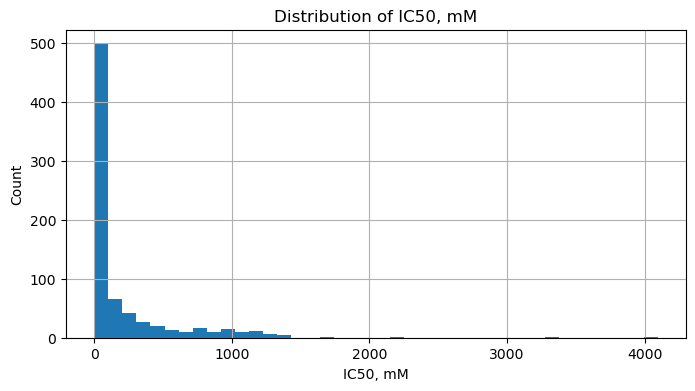

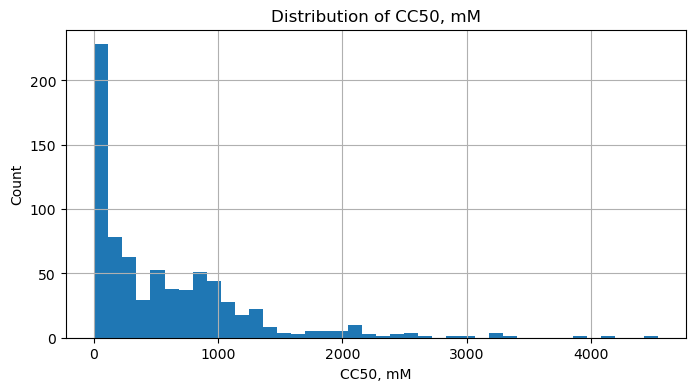

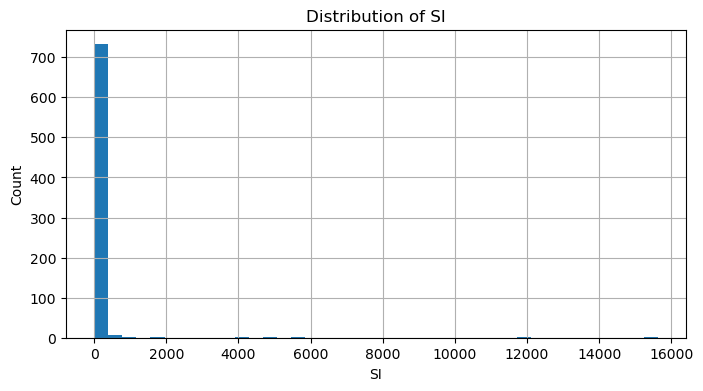

In [20]:
for target in TARGETS:
    plt.figure(figsize=(8, 4))
    plt.hist(train[target], bins=40)
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

### Логарифмированные распределения

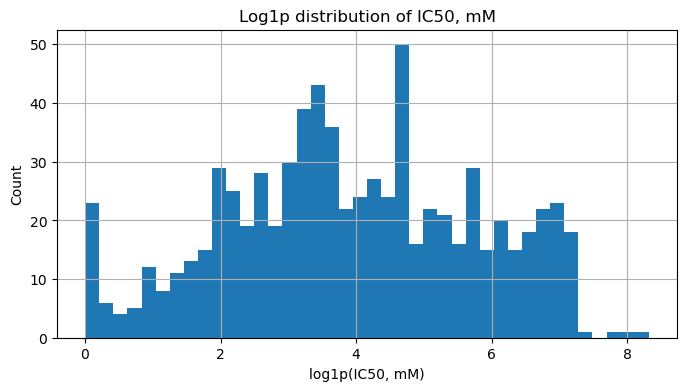

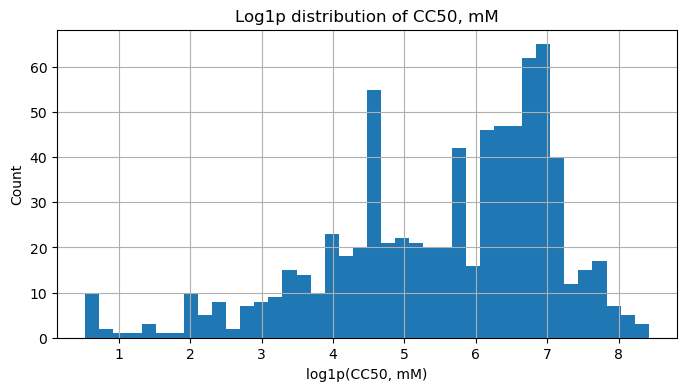

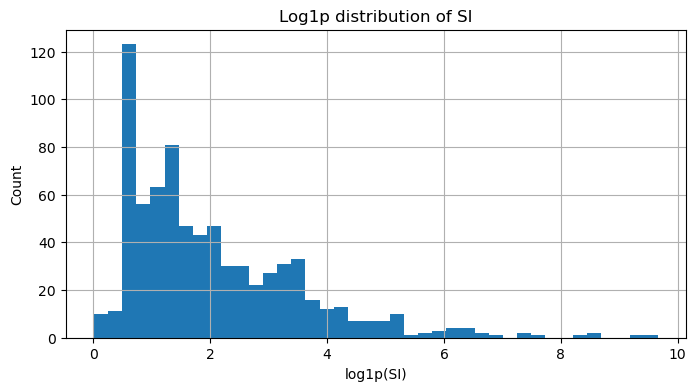

In [21]:
for target in TARGETS:
    plt.figure(figsize=(8, 4))
    plt.hist(np.log1p(train[target]), bins=40)
    plt.title(f"Log1p distribution of {target}")
    plt.xlabel(f"log1p({target})")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

В исходной шкале таргеты имеют сильные выбросы, а в лог-шкале структура видна лучше.

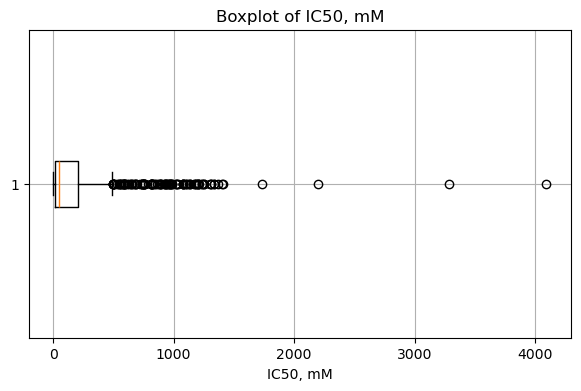

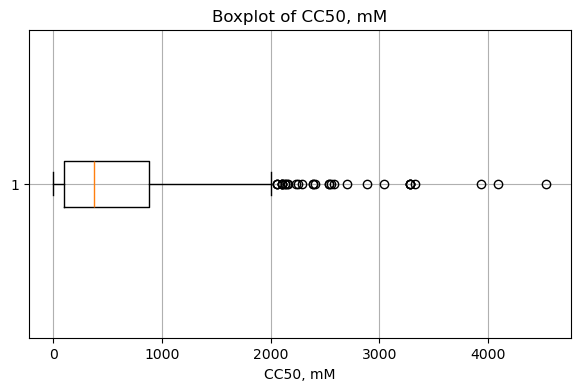

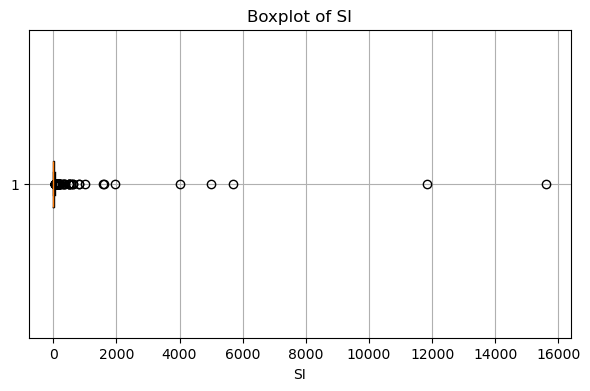

In [22]:
for target in TARGETS:
    plt.figure(figsize=(7, 4))
    plt.boxplot(train[target], vert=False)
    plt.title(f"Boxplot of {target}")
    plt.xlabel(target)
    plt.grid(True)
    plt.show()

По boxplot видно, что у всех трёх целевых переменных есть выбросы, особенно у SI. Это объясняет, почему RMSE чувствителен к отдельным экстремальным объектам.

### Scatter-plot

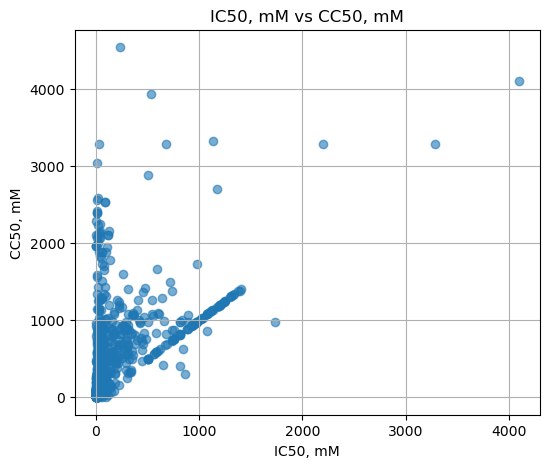

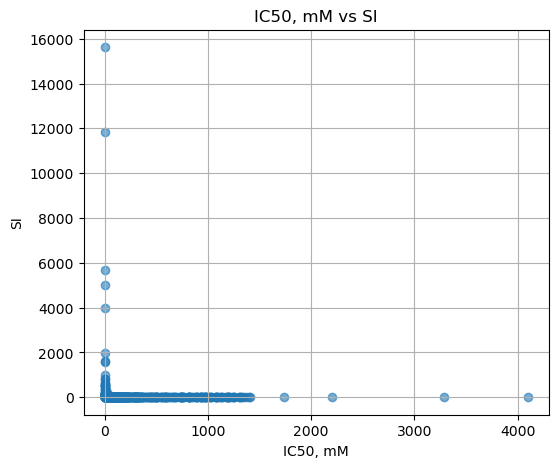

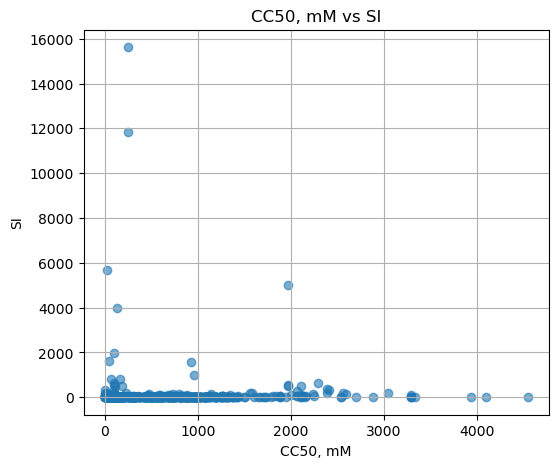

In [23]:
pairs = [
    ("IC50, mM", "CC50, mM"),
    ("IC50, mM", "SI"),
    ("CC50, mM", "SI")
]

for x_col, y_col in pairs:
    plt.figure(figsize=(6, 5))
    plt.scatter(train[x_col], train[y_col], alpha=0.6)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.grid(True)
    plt.show()

Лог версия скэттера:

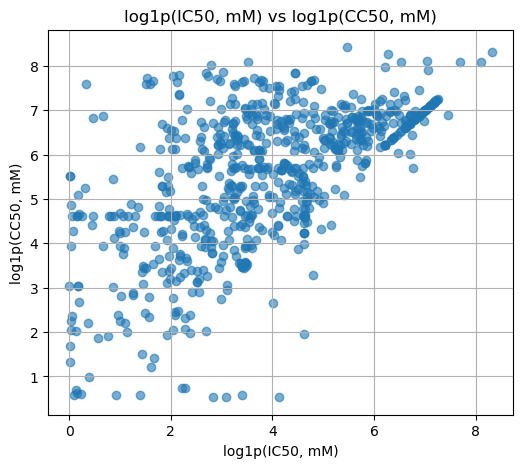

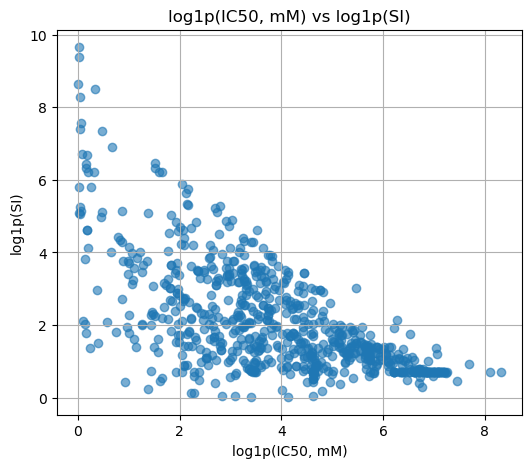

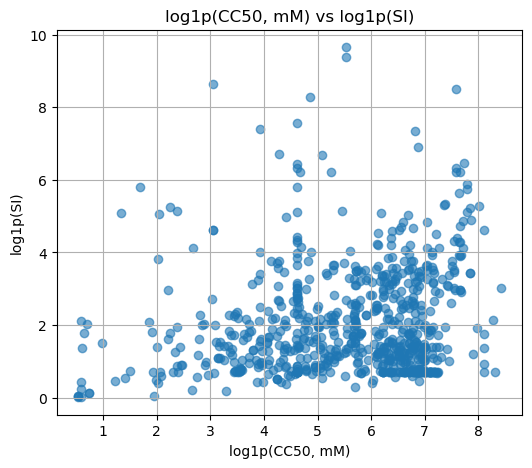

In [24]:
for x_col, y_col in pairs:
    plt.figure(figsize=(6, 5))
    plt.scatter(np.log1p(train[x_col]), np.log1p(train[y_col]), alpha=0.6)
    plt.xlabel(f"log1p({x_col})")
    plt.ylabel(f"log1p({y_col})")
    plt.title(f"log1p({x_col}) vs log1p({y_col})")
    plt.grid(True)
    plt.show()

## 3. Обучение модели ExtraTreesRegressor

In [25]:
et_model_grouped = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", MultiOutputRegressor(
            ExtraTreesRegressor(
                n_estimators=1500,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                max_features="sqrt",
                min_samples_leaf=1,
                bootstrap=False
            )
        ))
    ]
)

Модель ExtraTrees обёрнута в MultiOutputRegressor, то есть она обучает отдельную регрессию для каждого таргета, но в одном объекте sklearn.

In [26]:
def kaggle_rmse(y_true, y_pred):
    scores = []

    for i, target in enumerate(["IC50", "CC50", "SI"]):
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        scores.append(rmse)

    return np.mean(scores)

Функция считает метрику как среднее RMSE по трём таргетам.

In [27]:
def print_target_scores(y_true, y_pred, title=""):
    print(title)

    scores = []

    for i, target in enumerate(["IC50", "CC50", "SI"]):
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        scores.append(rmse)
        print(f"{target} RMSE: {rmse:.5f}")

    final_score = np.mean(scores)
    print(f"Final Kaggle-style RMSE: {final_score:.5f}")

    return final_score

In [28]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

et_grouped_oof = np.zeros((X_grouped.shape[0], len(TARGETS)))
et_grouped_test_folds = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_grouped), start=1):
    print(f"\nFold {fold}")

    X_train, X_valid = X_grouped.iloc[train_idx], X_grouped.iloc[valid_idx]
    y_train_log = np.log1p(y_grouped.iloc[train_idx])
    y_valid = y_grouped.iloc[valid_idx]

    fold_model = clone(et_model_grouped)

    fold_model.fit(X_train, y_train_log)

    valid_pred_log = fold_model.predict(X_valid)
    valid_pred = np.expm1(valid_pred_log)
    valid_pred = np.maximum(valid_pred, 1e-9)

    test_pred_log = fold_model.predict(X_test_clean)
    test_pred = np.expm1(test_pred_log)
    test_pred = np.maximum(test_pred, 1e-9)

    et_grouped_oof[valid_idx] = valid_pred
    et_grouped_test_folds.append(test_pred)

    print_target_scores(y_valid, valid_pred, title=f"Fold {fold}")

et_grouped_test = np.mean(et_grouped_test_folds, axis=0)

et_grouped_score = print_target_scores(
    y_grouped,
    et_grouped_oof,
    title="\nExtraTrees grouped OOF"
)


Fold 1
Fold 1
IC50 RMSE: 477.01181
CC50 RMSE: 654.89372
SI RMSE: 24.17905
Final Kaggle-style RMSE: 385.36153

Fold 2
Fold 2
IC50 RMSE: 296.93056
CC50 RMSE: 447.12097
SI RMSE: 358.94693
Final Kaggle-style RMSE: 367.66615

Fold 3
Fold 3
IC50 RMSE: 332.14139
CC50 RMSE: 372.13608
SI RMSE: 33.21303
Final Kaggle-style RMSE: 245.83017

Fold 4
Fold 4
IC50 RMSE: 269.44197
CC50 RMSE: 452.45434
SI RMSE: 33.03003
Final Kaggle-style RMSE: 251.64211

Fold 5
Fold 5
IC50 RMSE: 308.19156
CC50 RMSE: 411.65664
SI RMSE: 140.56715
Final Kaggle-style RMSE: 286.80511

ExtraTrees grouped OOF
IC50 RMSE: 344.55970
CC50 RMSE: 477.80003
SI RMSE: 174.00042
Final Kaggle-style RMSE: 332.12005


Кросс-валидация модели.

Что тут происходит:

- делим данные на 5 фолдов;
- обучаем модель;
- получаем OOF-предсказания;
- отдельно копим предсказания для test;
- делаем защиту от отрицательных значений через np.maximum(..., 1e-9).

In [29]:
print("Grouped score:", et_grouped_score)
print("X_grouped:", X_grouped.shape)

Grouped score: 332.12005178242765
X_grouped: (630, 186)


In [30]:
et_grouped_test.shape

(250, 3)

In [31]:
submission_grouped = sample_submission.copy()

submission_grouped["IC50"] = et_grouped_test[:, 0]
submission_grouped["CC50"] = et_grouped_test[:, 1]
submission_grouped["SI"] = et_grouped_test[:, 2]

submission_grouped.head()

,index,IC50,CC50,SI
0,0,43.589418,152.898995,4.840784
1,1,102.697782,352.937733,6.359180
2,2,54.605065,276.226309,6.821609
3,3,100.912673,192.216413,3.600157
4,4,134.373852,223.696525,2.048978


In [32]:
print(submission_grouped.shape)
print(submission_grouped.columns.tolist())

submission_grouped[["IC50", "CC50", "SI"]].describe()

(250, 4)
['index', 'IC50', 'CC50', 'SI']


,IC50,CC50,SI
count,250.000000,250.000000,250.000000
mean,157.829922,505.002575,51.507241
std,313.344240,511.984067,267.797580
min,0.669794,10.615462,0.964834
25%,27.702120,187.117741,3.396284
50%,55.076386,343.320862,6.031077
75%,137.614136,699.318215,16.359078
max,3306.920866,3467.053293,2180.730399


In [33]:
(submission_grouped[["IC50", "CC50", "SI"]] < 0).sum()

IC50    0
CC50    0
SI      0
dtype: int64

In [35]:
# submission_grouped.to_csv("../submissions/extratrees_grouped_clean.csv", index=False)

In [34]:
check_submission = pd.read_csv("../submissions/extratrees_grouped_clean.csv")

print(check_submission.shape)
print(check_submission.columns.tolist())
check_submission.head()

(250, 4)
['index', 'IC50', 'CC50', 'SI']


,index,IC50,CC50,SI
0,0,43.589418,152.898995,4.840784
1,1,102.697782,352.937733,6.359180
2,2,54.605065,276.226309,6.821609
3,3,100.912673,192.216413,3.600157
4,4,134.373852,223.696525,2.048978


## 5. Очистка train от шума и еще одно обучение

Снова создаём ключи одинаковых строк и считаем статистики по дублям.

Главное отличие:
тут уже считается SI_cv — коэффициент вариации SI.

In [36]:
train_keys = pd.util.hash_pandas_object(X_clean, index=False).astype(str)

train_with_key = train.copy()
train_with_key["_key"] = train_keys.values

dup_stats = (
    train_with_key
    .groupby("_key")
    .agg(
        count=("index", "count"),

        IC50_mean=("IC50, mM", "mean"),
        IC50_std=("IC50, mM", "std"),
        IC50_min=("IC50, mM", "min"),
        IC50_max=("IC50, mM", "max"),

        CC50_mean=("CC50, mM", "mean"),
        CC50_std=("CC50, mM", "std"),
        CC50_min=("CC50, mM", "min"),
        CC50_max=("CC50, mM", "max"),

        SI_mean=("SI", "mean"),
        SI_std=("SI", "std"),
        SI_min=("SI", "min"),
        SI_max=("SI", "max"),
    )
    .reset_index()
)

dup_stats = dup_stats[dup_stats["count"] > 1].copy()

dup_stats["IC50_cv"] = dup_stats["IC50_std"] / (dup_stats["IC50_mean"] + 1e-9)
dup_stats["CC50_cv"] = dup_stats["CC50_std"] / (dup_stats["CC50_mean"] + 1e-9)
dup_stats["SI_cv"] = dup_stats["SI_std"] / (dup_stats["SI_mean"] + 1e-9)

dup_stats.sort_values("SI_cv", ascending=False).head(30)

,_key,count,IC50_mean,IC50_std,IC50_min,IC50_max,CC50_mean,CC50_std,CC50_min,CC50_max,SI_mean,SI_std,SI_min,SI_max,IC50_cv,CC50_cv,SI_cv
561,8093754041653173835,16,9.475038,14.233891,0.016004,49.898692,242.241640,480.599295,0.700995,1805.081735,1470.412209,3923.379588,0.027594,15620.600000,1.502252,1.983966,2.668218
462,5359894422975982717,10,34.342232,29.407388,0.601637,64.196649,173.240377,156.797962,0.700808,499.986777,26.933091,50.150607,0.011489,166.208791,0.856304,0.905089,1.862044
443,4972505171501264594,7,0.316502,0.485677,0.003517,1.399644,87.928898,82.372200,19.999437,250.001758,2694.841865,4518.031640,71.447236,11848.333333,1.534514,0.936805,1.676548
4,10091642533791176640,3,1839.225423,1655.576553,32.843311,3284.331113,3284.331113,0.000000,3284.331113,3284.331113,34.164179,57.016025,1.000000,100.000000,0.900149,0.000000,1.668883
75,12174236541213400051,3,78.064012,63.957644,4.212087,114.989975,2106.043502,0.000000,2106.043502,2106.043502,178.876679,278.100954,18.315018,500.000000,0.819297,0.000000,1.554708
389,3542825712473130627,3,68.666894,54.270531,6.000683,100.000000,100.000000,0.000000,100.000000,100.000000,6.221590,9.044059,1.000000,16.664769,0.790345,0.000000,1.453657
383,3352877390422931399,13,51.239843,71.255563,2.198936,255.928324,1065.940681,1090.834739,1.101516,3039.683222,38.665259,55.195329,0.126588,197.898694,1.390628,1.023354,1.427517
399,3883317840206820646,2,672.263687,931.898198,13.312152,1331.215222,1042.785257,407.901568,754.355292,1331.215222,28.833333,39.362277,1.000000,56.666667,1.386209,0.391165,1.365166
131,13795675766250167077,2,43.391170,54.417470,4.912208,81.870132,194.714464,110.571668,116.528488,272.900440,28.489444,38.277261,1.423333,55.555556,1.254114,0.567866,1.343559
213,15593619804075332110,2,60.189475,64.476367,14.597799,105.781151,232.189628,204.200095,87.798356,376.580899,13.313551,17.654407,0.830000,25.797101,1.071223,0.879454,1.326048


In [37]:
bad_dup_keys = dup_stats[
    (dup_stats["SI_cv"] > 1.0) |
    (dup_stats["IC50_cv"] > 1.0) |
    (dup_stats["CC50_cv"] > 1.0)
]["_key"].tolist()

print("Bad duplicate groups:", len(bad_dup_keys))

clean_mask = ~train_with_key["_key"].isin(bad_dup_keys)

train_cleaned = train_with_key.loc[clean_mask].drop(columns=["_key"]).copy()

print("Before:", train.shape)
print("After:", train_cleaned.shape)
print("Removed rows:", train.shape[0] - train_cleaned.shape[0])

Bad duplicate groups: 30
Before: (751, 214)
After: (640, 214)
Removed rows: 111


Удаляем проблемные дубликатные группы.
Мы обнаружили группы объектов с полностью одинаковыми молекулярными дескрипторами, но сильно различающимися целевыми значениями. Такие строки создают противоречивый обучающий сигнал: для одного и того же X модель видит разные y. Поэтому мы удалили наиболее шумные группы, чтобы модель обучалась на более согласованных данных.

In [38]:
TARGETS = ['IC50, mM', 'CC50, mM', 'SI']
ID_COL = 'index'

X_train_cleaned = train_cleaned.drop(columns=TARGETS + [ID_COL])
y_train_cleaned = train_cleaned[TARGETS].copy()

# оставляем те же колонки, что и в X_clean
X_train_cleaned = X_train_cleaned[X_clean.columns]

print(X_train_cleaned.shape)
print(y_train_cleaned.shape)

(640, 186)
(640, 3)


После удаления шумных строк и бесполезных признаков осталось 640 объектов, 186 признаков и 3 таргета.

In [39]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_cleaned = np.zeros((X_train_cleaned.shape[0], 3))
test_cleaned_folds = []

for target_idx, target in enumerate(TARGETS):
    print("\nTARGET:", target)

    target_test_folds = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_cleaned), start=1):
        X_tr = X_train_cleaned.iloc[tr_idx]
        X_val = X_train_cleaned.iloc[val_idx]

        y_tr = y_train_cleaned.iloc[tr_idx][target]
        y_val = y_train_cleaned.iloc[val_idx][target]

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesRegressor(
                n_estimators=2500,
                random_state=42 + fold,
                n_jobs=-1,
                max_features=0.7,
                min_samples_leaf=2,
                bootstrap=False
            ))
        ])

        model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test_clean)

        val_pred = np.maximum(val_pred, 1e-9)
        test_pred = np.maximum(test_pred, 1e-9)

        oof_cleaned[val_idx, target_idx] = val_pred
        target_test_folds.append(test_pred)

    rmse = root_mean_squared_error(y_train_cleaned[target], oof_cleaned[:, target_idx])
    print("RMSE:", rmse)

    test_cleaned_folds.append(np.mean(target_test_folds, axis=0))


TARGET: IC50, mM
RMSE: 304.04494736186945

TARGET: CC50, mM
RMSE: 439.8589238532537

TARGET: SI
RMSE: 98.97196625810606


Финальное обучение лучшей модели (ПОКА ЧТО!).

Что происходит:

- используется KFold(n_splits=5);
- для каждого таргета обучается отдельный ExtraTreesRegressor;
- пропуски заполняются медианой;
- модель обучается на train folds;
- предсказывает validation fold;
- предсказывает test;
- test-предсказания усредняются по фолдам.

Ключевой момент здесь то, что это не одна multi-output модель, а три отдельные модели, по одной на каждый таргет.

In [40]:
cleaned_score = (
    root_mean_squared_error(y_train_cleaned["IC50, mM"], oof_cleaned[:, 0]) +
    root_mean_squared_error(y_train_cleaned["CC50, mM"], oof_cleaned[:, 1]) +
    root_mean_squared_error(y_train_cleaned["SI"], oof_cleaned[:, 2])
) / 3

print("Cleaned train score:", cleaned_score)

Cleaned train score: 280.9586124910764


In [41]:
cleaned_test_pred = np.column_stack(test_cleaned_folds)

print(cleaned_test_pred.shape)

(250, 3)


In [42]:
submission_cleaned_train = sample_submission.copy()

submission_cleaned_train["IC50"] = cleaned_test_pred[:, 0]
submission_cleaned_train["CC50"] = cleaned_test_pred[:, 1]
submission_cleaned_train["SI"] = cleaned_test_pred[:, 2]

display(submission_cleaned_train.head())
display(submission_cleaned_train[["IC50", "CC50", "SI"]].describe())

,index,IC50,CC50,SI
0,0,165.430179,265.932686,11.304419
1,1,135.998916,362.806859,6.436607
2,2,49.594876,314.381758,7.246385
3,3,352.257365,398.549588,9.402399
4,4,214.268484,287.614863,2.548238


,IC50,CC50,SI
count,250.000000,250.000000,250.000000
mean,263.758279,657.966700,27.558343
std,315.361426,502.178623,51.621105
min,5.904032,23.541590,1.372192
25%,76.401313,315.016498,6.887817
50%,149.856920,517.449541,12.361243
75%,321.283237,874.823319,28.468081
max,2171.050489,2758.205561,454.403886


In [43]:
print(submission_cleaned_train.shape)
print(submission_cleaned_train.columns.tolist())

print(submission_cleaned_train.isna().sum())
print(np.isinf(submission_cleaned_train[["IC50", "CC50", "SI"]]).sum())

display(submission_cleaned_train.describe())

(250, 4)
['index', 'IC50', 'CC50', 'SI']
index    0
IC50     0
CC50     0
SI       0
dtype: int64
IC50    0
CC50    0
SI      0
dtype: int64


,index,IC50,CC50,SI
count,250.000000,250.000000,250.000000,250.000000
mean,124.500000,263.758279,657.966700,27.558343
std,72.312977,315.361426,502.178623,51.621105
min,0.000000,5.904032,23.541590,1.372192
25%,62.250000,76.401313,315.016498,6.887817
50%,124.500000,149.856920,517.449541,12.361243
75%,186.750000,321.283237,874.823319,28.468081
max,249.000000,2171.050489,2758.205561,454.403886


In [46]:
# submission_cleaned_train.to_csv(
#     "../submissions/extratrees_cleaned_train_bad_dups_removed.csv",
#     index=False
# )

In [44]:
check = pd.read_csv("../submissions/extratrees_cleaned_train_bad_dups_removed.csv")

print(check.shape)
print(check.columns.tolist())
display(check.head())
display(check.describe())

(250, 4)
['index', 'IC50', 'CC50', 'SI']


,index,IC50,CC50,SI
0,0,165.430179,265.932686,11.304419
1,1,135.998916,362.806859,6.436607
2,2,49.594876,314.381758,7.246385
3,3,352.257365,398.549588,9.402399
4,4,214.268484,287.614863,2.548238


,index,IC50,CC50,SI
count,250.000000,250.000000,250.000000,250.000000
mean,124.500000,263.758279,657.966700,27.558343
std,72.312977,315.361426,502.178623,51.621105
min,0.000000,5.904032,23.541590,1.372192
25%,62.250000,76.401313,315.016498,6.887817
50%,124.500000,149.856920,517.449541,12.361243
75%,186.750000,321.283237,874.823319,28.468081
max,249.000000,2171.050489,2758.205561,454.403886


In [45]:
best_clean_oof = oof_cleaned.copy()
best_clean_test = np.column_stack(test_cleaned_folds).copy()
best_clean_score = cleaned_score

print(best_clean_score)

280.9586124910764


Распределния таргетов до и после чистки:

In [47]:
comparison_stats = []

for target in TARGETS:
    comparison_stats.append({
        "target": target,
        "dataset": "before_cleaning",
        "count": train[target].count(),
        "mean": train[target].mean(),
        "median": train[target].median(),
        "std": train[target].std(),
        "q95": train[target].quantile(0.95),
        "q99": train[target].quantile(0.99),
        "max": train[target].max()
    })
    
    comparison_stats.append({
        "target": target,
        "dataset": "after_cleaning",
        "count": y_train_cleaned[target].count(),
        "mean": y_train_cleaned[target].mean(),
        "median": y_train_cleaned[target].median(),
        "std": y_train_cleaned[target].std(),
        "q95": y_train_cleaned[target].quantile(0.95),
        "q99": y_train_cleaned[target].quantile(0.99),
        "max": y_train_cleaned[target].max()
    })

comparison_stats_df = pd.DataFrame(comparison_stats)
display(comparison_stats_df)

,target,dataset,count,mean,median,std,q95,q99,max
0,"IC50, mM",before_cleaning,751,204.544021,44.069306,370.367937,1002.304418,1334.274334,4095.188563
1,"IC50, mM",after_cleaning,640,215.419998,57.360105,358.863134,1019.531796,1309.128993,4095.188563
2,"CC50, mM",before_cleaning,751,577.426098,376.580899,641.515163,1883.480370,3162.007168,4538.976189
3,"CC50, mM",after_cleaning,640,570.870903,446.970005,597.309726,1600.149401,2655.761885,4538.976189
4,SI,before_cleaning,751,89.153313,4.000000,788.882198,138.433453,1281.250000,15620.600000
5,SI,after_cleaning,640,22.070312,3.629536,101.285950,66.666667,298.958333,1618.888889


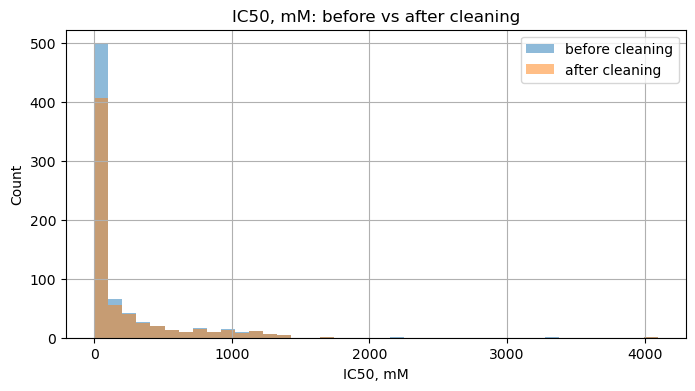

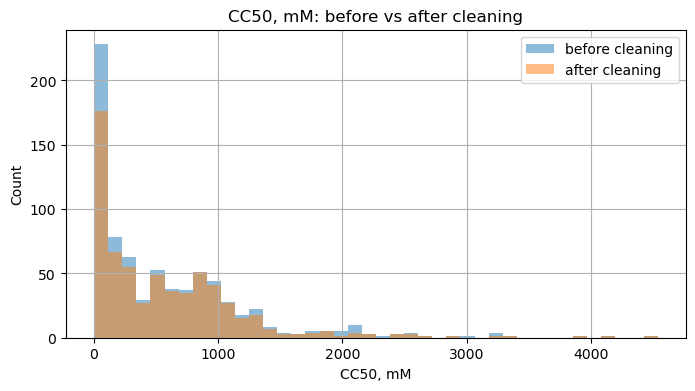

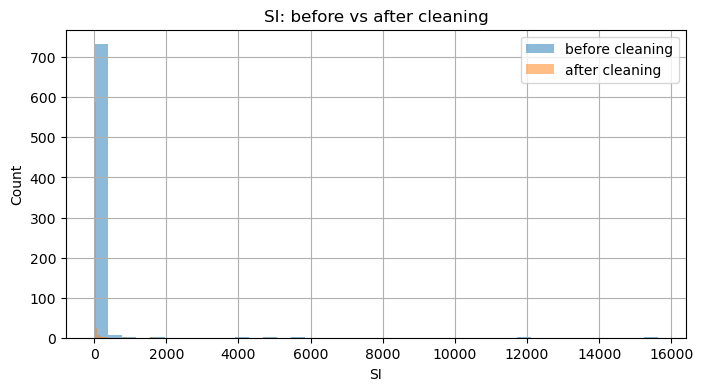

In [48]:
for target in TARGETS:
    plt.figure(figsize=(8, 4))
    plt.hist(train[target], bins=40, alpha=0.5, label="before cleaning")
    plt.hist(y_train_cleaned[target], bins=40, alpha=0.5, label="after cleaning")
    plt.title(f"{target}: before vs after cleaning")
    plt.xlabel(target)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()

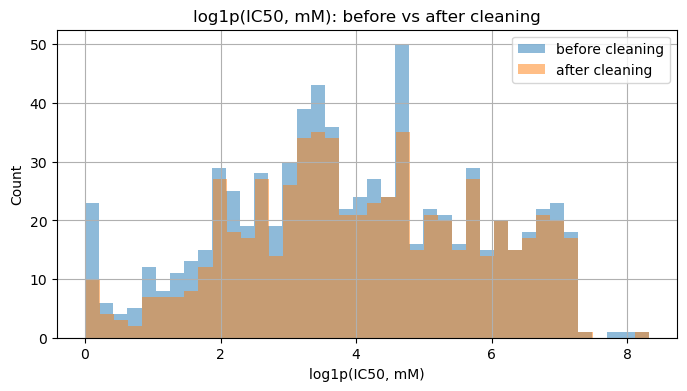

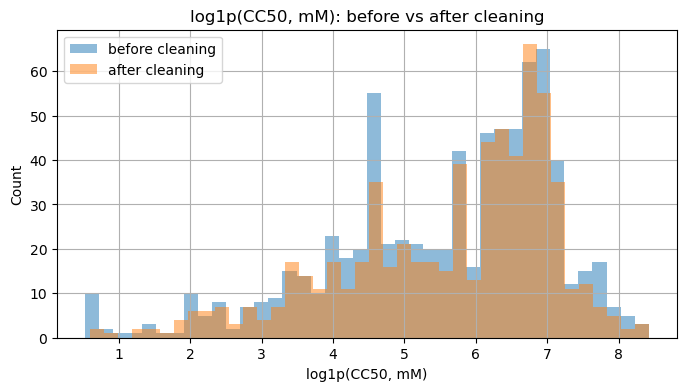

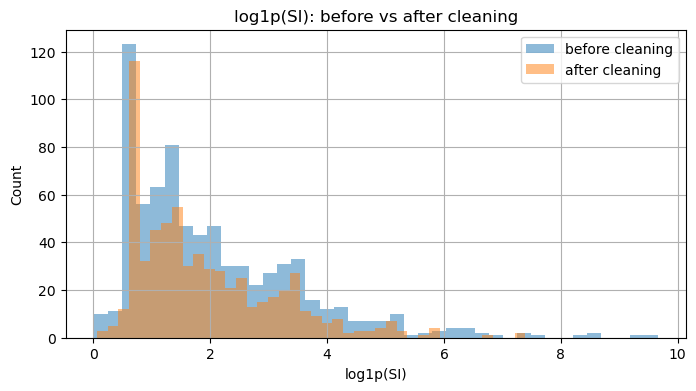

In [49]:
for target in TARGETS:
    plt.figure(figsize=(8, 4))
    plt.hist(np.log1p(train[target]), bins=40, alpha=0.5, label="before cleaning")
    plt.hist(np.log1p(y_train_cleaned[target]), bins=40, alpha=0.5, label="after cleaning")
    plt.title(f"log1p({target}): before vs after cleaning")
    plt.xlabel(f"log1p({target})")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()

Другие модели дали ухудшение на Kaggle на тестовых данных. Лучшей осталась модель ExtraTrees

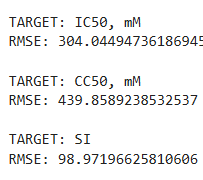